In [1]:
import os, sys
import time
import matplotlib.pyplot as plt
import numpy as np
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls

In [2]:
# Set the path to the simulation setup file 
cwd = os.path.abspath('..')
session_path = os.path.join(cwd, 'ZimT')
zimt_device_parameters = os.path.join(session_path, 'simulation_setup.txt')

In [3]:
# Set the simulation parameters 
tVG_name = os.path.join(session_path, 'tVG.txt')
f_min = 1e-2
f_max = 1e10
f_steps = 20
V = 0
G_frac = 1 
GStep = 0.05

In [4]:
# Run the IMPLS simulation
t_0 = time.perf_counter()
ret, mess = impls.run_IMPLS_simu(zimt_device_parameters, session_path, f_min, f_max, f_steps, V, G_frac, GStep, tVG_name=tVG_name, output_file="freqP.dat", tj_name='tj.dat', varFile='varFile.dat', verbose=True)
t_1 = time.perf_counter()

/Users/joshedmundson/SIMsalabim-Installs/Unoficial-IMPLS-SIMsalabim/pySIMsalabim/SIMsalabim/ZimT



In [5]:
# Let's look at the recombination/photoluminescence data up until termination 
import pandas as pd 

data = pd.read_csv('varFile.dat', sep=r'\s+')

# Integrate direct recombination over x, position within the material
data = impls.integrate_fxt_dx(data, 'Rdir', x_name='x', t_name='time')


In [6]:
# Find the number of non-convergent runs 
divergent_count = 0

log = open("log.txt", "r")

for line in log:
    # Remove leading spaces and new line char
    line = line.strip()
    line = line.split(" ")

    if "Skipping" in line:
        divergent_count += 1

In [7]:
# Print General Runtime Stats to get some idea of where the simulation got to and
# Print how far the simulation managed to get before timing out 
t_max_actual = data['time'].iloc[-1]
t_max_target = 1/f_min

print("**TIME**")
# print(f"Runtime: {t_1-t_0:.4}s")
print(f"Actual Max Simulation Time: {t_max_actual}s")
print(f"Target Max Simulation Time: {t_max_target}s")
print(f"Simulation progress: {t_max_actual/t_max_target*100:.4}%")

# Calculate the number of main loops completed or skipped 
no_loops_completed = data["time"].count()
total_no_loops_run = no_loops_completed + divergent_count

print("**CONVERGENCE**")
print(f"Total number of time steps simulated: {total_no_loops_run}")
print(f"No Divergent Timesteps: {divergent_count}")
print(f"Divergence Percentage: {divergent_count/total_no_loops_run*100:.3}%")

**TIME**
Actual Max Simulation Time: 100.8s
Target Max Simulation Time: 100.0s
Simulation progress: 100.8%
**CONVERGENCE**
Total number of time steps simulated: 1548
No Divergent Timesteps: 0
Divergence Percentage: 0.0%


In [8]:
# Run the IMPLS code on the recombination data to get the IMPLS transfer function P
result, message = impls.get_IMPLS(data, f_min, f_max, f_steps, session_path, 'freqP.dat')

In [9]:
# Read in the IMPLS data
impls_data = pd.read_csv('freqP.dat', sep=r'\s+')
impls_data.head()

,freq,ReP,ImP
0,9.157509e+09,6.246684e+13,6.543273e+12
1,8.090615e+09,6.200642e+13,8.230864e+12
2,7.147963e+09,6.142771e+13,1.011549e+13
3,6.321113e+09,6.068249e+13,1.240599e+13
4,5.595971e+09,5.978377e+13,1.494599e+13


In [10]:
impls_data.tail()

,freq,ReP,ImP
228,0.015038,-3.110452e+19,1.361672e+13
229,0.013353,-3.110452e+19,1.209076e+13
230,0.011857,-3.110452e+19,1.073682e+13
231,0.010529,-3.110452e+19,9.533234e+12
232,0.009921,-3.110452e+19,8.981928e+12


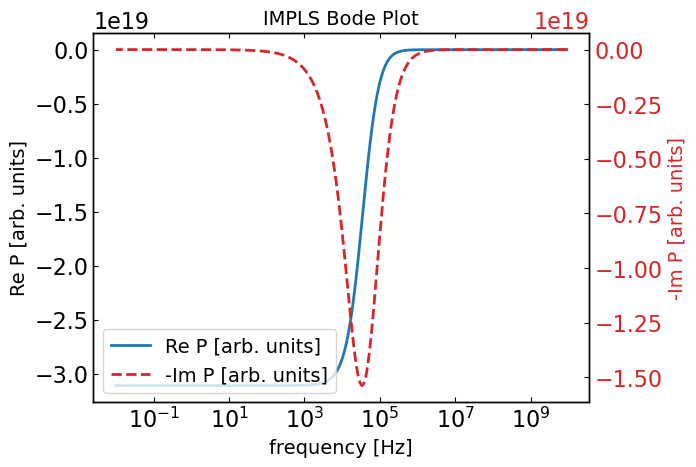

In [11]:
# Plot the IMPLS data 
impls.IMPLS_plot(session_path, output_file='freqP.dat', xscale='log', yscale1='linear', yscale2='linear')

In [12]:
# Find the peak frequency of Im P, as this corresponds to the characteristic RC frequency of the optical equivalent circuit (OEC)
max_ImP = impls_data['ImP'].abs().max()
max_row = impls_data[impls_data['ImP'].abs() == max_ImP]
max_freq = max_row['freq'].values[0]

max_row


,freq,ReP,ImP
105,33422.46,-1.602500e+19,1.537896e+19


In [13]:
impls_data['ReP'].iloc[116]

np.float64(-2.906853e+19)

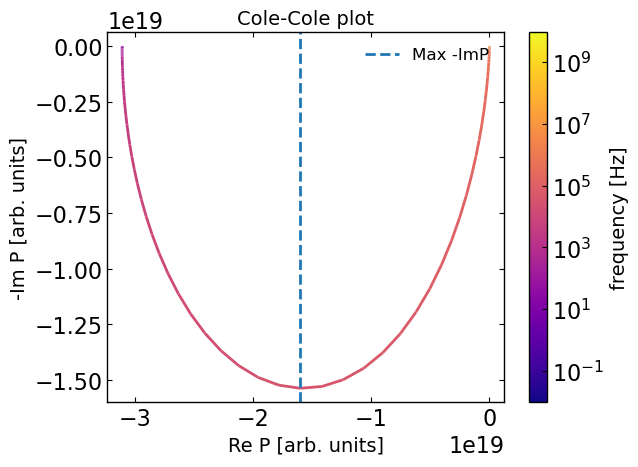

In [14]:
# We can then plot this frequency on a Nyquist plot 
impls.ColeCole_plot(session_path, output_file='freqP.dat', xscale='linear', yscale='linear', plot=False)
plt.axvline(max_row['ReP'].values[0], linestyle='--', label='Max -ImP')
plt.legend(frameon=False, fontsize=12)
plt.show()

In [15]:
# Fit the OEC to the data to get a better estimation of peak value 
def P(freq, R0, R1, C1):
    omega = 2*np.pi*freq
    ReP = R0 + R1/(1 + (omega*R1*C1)**2)
    ImP = -(omega*(R1**2)*C1)/(1+(omega*R1*C1)**2)
    return [ReP, ImP]

def f_ReP(freq, R0, R1, C1): 
    omega = 2*np.pi*freq
    ReP = R0 + R1/(1 + (omega*R1*C1)**2)
    return ReP

def f_ImP(freq, R0, R1, C1):
    omega = 2*np.pi*freq
    ImP = -(omega*(R1**2)*C1)/(1+(omega*R1*C1)**2)
    return ImP

In [16]:
P(max_freq, 0, 1E20, 1E-25)

[np.float64(1.848435872768944e+19), np.float64(-3.881706268118488e+19)]

In [17]:
# Fit the function to the data
import scipy.optimize as so 

# To get around the fact scipy can't fit complex functions, or vector functions, I'm going to to fit [ReP, Imp] to [freq, freq]
def P_flat(freq, R0, R1, C1):
    l = int(len(freq)/2)
    ReP = f_ReP(freq[:l], R0, R1, C1)
    ImP = f_ImP(freq[:l], R0, R1, C1)
    return np.append(ReP, ImP)

flat_freq = np.append(impls_data['freq'], impls_data['freq'])
flat_P = np.append(impls_data['ReP'], impls_data['ImP'])

params, cov = so.curve_fit(P_flat, flat_freq, flat_P, [0, 3.1E19, 5.1E-25], )

params


/var/folders/0m/gfqnwnj15yb3_ysgltf_03440000gn/T/ipykernel_71451/1415046703.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cov = so.curve_fit(P_flat, flat_freq, flat_P, [0, 3.1E19, 5.1E-25], )


array([ 0.00000000e+00, -2.88108655e+19,  1.16763000e-25])

In [18]:
# Try to calculate what we expect to be the characteristic frequency based radiative recombination lifetime
k_dir = 1E-17 #m^3 s^-1
N_cv = 2.2E24 #m^-3
E_g = 2 #eV
k_B = 1.380649E-23 # J/K
T = 295 # K
q_e = 1.6E-19 #C
f_n0p0 = 2*k_dir*N_cv*np.exp(-(E_g*q_e)/(2*k_B*T))
f_n0p0

np.float64(3.8253242625822647e-10)

In [19]:
G = 1E27
f_G = 2*np.sqrt(k_dir*G)
f_G

np.float64(200000.0)

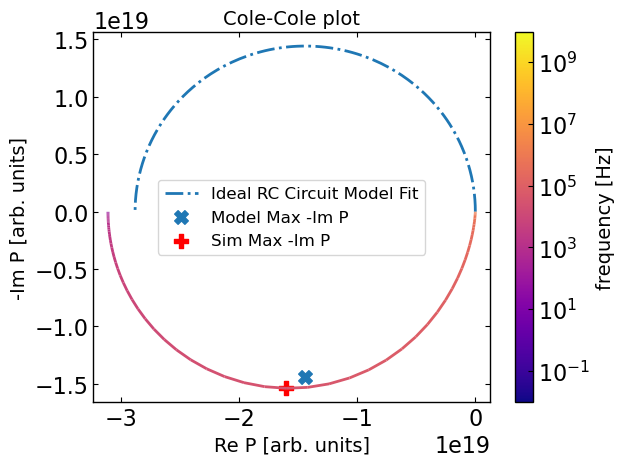

In [20]:
freq_range_model = np.geomspace(f_max, f_min, 1000)
ReP_model = f_ReP(freq_range_model, *params)
ImP_model = f_ImP(freq_range_model, *params)

# Calculate characteristic RC frequency according to the model
f_char_model = 1/(params[1]*params[2])
ReP_char_model = f_ReP(f_char_model/(2*np.pi), *params)
ImP_char_model = f_ImP(f_char_model/(2*np.pi), *params)


# Try plotting the fitted data over the Nyquist Plot 
impls.ColeCole_plot(session_path, output_file='freqP.dat', xscale='linear', yscale='linear', plot=False)
plt.plot(ReP_model, -ImP_model, linestyle='-.', label='Ideal RC Circuit Model Fit')

plt.scatter(ReP_char_model, -ImP_char_model, marker='X', s=96, label='Model Max -Im P')
plt.scatter(max_row['ReP'].values[0], -max_row['ImP'].values[0], marker='P', s=96, label='Sim Max -Im P', color='red')

plt.legend(fontsize=12)
plt.show()

In [21]:
# Compare the fit for the peak ImP freq we found 
ReP, ImP = P(max_freq, *params)
print(f"Calculated P: {ReP:.3} +j {ImP:.3}")
print(f"Calculated ReP, ImP: {f_ReP(max_freq, *params):.3} +j {f_ImP(max_freq, *params):.3}")
print(f"Simulated P: {max_row['ReP'].values[0]:.3} +j {max_row['ImP'].values[0]:.3}")

Calculated P: -1.92e+19 +j -1.36e+19
Calculated ReP, ImP: -1.92e+19 +j -1.36e+19
Simulated P: -1.6e+19 +j 1.54e+19


In [24]:
# Print all characteristic frequencies
print(f"Simulated characteristic freq: {max_freq:.3}Hz")
print(f"Ideal RC circuit model characteristic freq: {f_char_model:.3}Hz")
print(f"Calculated characteristic freq (n0p0): {f_n0p0:.3}Hz")
print(f"Calculated characteristic frequency (G): {f_G:.3}Hz")

Simulated characteristic freq: 3.34e+04Hz
Ideal RC circuit model characteristic freq: -2.97e+05Hz
Calculated characteristic freq (n0p0): 3.83e-10Hz
Calculated characteristic frequency (G): 2e+05Hz


In [23]:
# # Clean up the output files (comment out if you want to keep the output files)
# sim.clean_all_output(session_path)
# sim.clean_up_output('freqY',session_path)
# sim.delete_folders('tmp',session_path)
# sim.clean_up_output('varFile.dat', session_path)
# sim.clean_up_output('freqP.dat', session_path)